# Notebook 18 - Inferensi Citra Tunggal dengan FFT + CLIP

Notebook ini digunakan untuk menguji satu atau beberapa citra baru menggunakan konfigurasi fitur FFT + CLIP. Jika model terbaik FFT + CLIP sudah tersimpan, notebook akan langsung memuat model tersebut. Jika model belum tersedia, notebook akan melatih ulang model dengan konfigurasi yang sama seperti eksperimen FFT + CLIP, kemudian menyimpannya untuk digunakan kembali.

Catatan: model pada penelitian ini dilatih pada subset GenImage yang dibatasi pada empat kelas kucing. Prediksi pada citra di luar domain tersebut tetap dapat dihitung, tetapi interpretasinya perlu lebih hati-hati.


In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
from PIL import Image as PILImage

import torch
from transformers import AutoProcessor, CLIPModel

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from IPython.display import display

warnings.filterwarnings("ignore")

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path("..").resolve()
else:
    PROJECT_ROOT = Path(".").resolve()

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
MODEL_DIR = ARTIFACT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

VECTOR_PATH = ARTIFACT_DIR / "feature_vector_biggan_midjourney_cat4_fft_clip.csv"
MODEL_PATH = MODEL_DIR / "fft_clip_best_model.joblib"
PREDICTION_OUT = ARTIFACT_DIR / "single_image_inference_fft_clip.csv"

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
THRESHOLD = 0.5

print("Project root:", PROJECT_ROOT)
print("Vector path:", VECTOR_PATH)
print("Model path:", MODEL_PATH)


/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold
Vector path: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/feature_vector_biggan_midjourney_cat4_fft_clip.csv
Model path: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/models/fft_clip_best_model.joblib


## 1. Muat Feature Vector Eksperimen FFT + CLIP

Feature vector ini digunakan apabila model belum tersimpan dan perlu dilatih ulang. Split data mengikuti eksperimen sebelumnya, yaitu 80:20 dengan `random_state=42` dan stratifikasi berdasarkan generator, label AI/nature, dan kelas objek.


In [2]:
data = pd.read_csv(VECTOR_PATH)

meta_cols = [
    "image_id",
    "path",
    "relative_path",
    "generator",
    "subset_name",
    "split",
    "class_name",
    "content_id",
    "content_label",
    "is_real",
    "y_ai",
]

feature_cols = [c for c in data.columns if c not in meta_cols]
X = data[feature_cols]
y = data["y_ai"].astype(int)

stratify_key = (
    data["generator"].astype(str)
    + "|"
    + data["y_ai"].astype(str)
    + "|"
    + data["content_label"].astype(str)
)

X_train, X_eval, y_train, y_eval, train_idx, eval_idx = train_test_split(
    X,
    y,
    data.index.to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=stratify_key,
)

print("Data shape:", data.shape)
print("Jumlah fitur:", len(feature_cols))
print("Train:", X_train.shape[0], "Testing:", X_eval.shape[0])


Data shape: (1600, 79)
Jumlah fitur: 68
Train: 1280 Testing: 320


## 2. Muat Model atau Latih Ulang

Jika `artifacts/models/fft_clip_best_model.joblib` sudah ada, model akan langsung digunakan. Jika belum ada, notebook melatih XGBoost dan MLP dengan konfigurasi yang sama seperti eksperimen FFT + CLIP, lalu memilih model terbaik berdasarkan AUROC, F1-score, dan accuracy.


In [3]:
def train_fft_clip_models():
    models = {
        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=42,
        ),
        "MLP": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "clf",
                    MLPClassifier(
                        hidden_layer_sizes=(128, 64),
                        activation="relu",
                        max_iter=500,
                        random_state=42,
                    ),
                ),
            ]
        ),
    }

    rows = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        score_ai = model.predict_proba(X_eval)[:, 1]
        pred_ai = (score_ai >= THRESHOLD).astype(int)

        rows.append(
            {
                "model": name,
                "accuracy": accuracy_score(y_eval, pred_ai),
                "f1": f1_score(y_eval, pred_ai),
                "auroc": roc_auc_score(y_eval, score_ai),
            }
        )

    results_df = (
        pd.DataFrame(rows)
        .sort_values(by=["auroc", "f1", "accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    best_model_name = results_df.loc[0, "model"]
    best_model = models[best_model_name]

    bundle = {
        "model": best_model,
        "feature_cols": feature_cols,
        "threshold": THRESHOLD,
        "feature_set": "FFT + CLIP",
        "model_name": best_model_name,
        "metrics": results_df.to_dict(orient="records"),
    }
    joblib.dump(bundle, MODEL_PATH)
    return bundle, results_df


if MODEL_PATH.exists():
    bundle = joblib.load(MODEL_PATH)
    results_df = pd.DataFrame(bundle.get("metrics", []))
    print("Model dimuat dari:", MODEL_PATH)
else:
    bundle, results_df = train_fft_clip_models()
    print("Model belum ada, model dilatih ulang dan disimpan ke:", MODEL_PATH)

clf = bundle["model"]
feature_cols = bundle["feature_cols"]
threshold = bundle.get("threshold", THRESHOLD)

print("Model digunakan:", bundle.get("model_name", type(clf).__name__))
display(results_df)


Model dimuat dari: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/models/fft_clip_best_model.joblib
Model digunakan: XGBoost


,model,accuracy,f1,auroc
0,XGBoost,0.990625,0.990596,0.999766
1,MLP,0.971875,0.971963,0.997383


## 3. Fungsi Ekstraksi Fitur untuk Gambar Baru

Bagian ini membuat ulang ekstraksi fitur FFT dan CLIP untuk satu citra. Fitur FFT terdiri atas rata-rata magnitudo, rata-rata fase, rata-rata kosinus fase, dan rata-rata sinus fase. Fitur CLIP diambil dari 64 dimensi pertama embedding visual CLIP setelah normalisasi.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
clip_model.eval()

print("Device:", device)


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8711.09it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cpu


In [5]:
def resolve_image_path(image_path):
    path = Path(image_path)
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    return path.resolve()


def extract_fft_mean(image_path):
    gray = np.asarray(PILImage.open(image_path).convert("L"), dtype=np.float32)
    f = np.fft.fft2(gray)
    mag = np.abs(f)
    phase = np.angle(f)
    return {
        "fft_mag_mean": float(np.mean(mag)),
        "fft_phase_mean": float(np.mean(phase)),
        "fft_phase_cos_mean": float(np.mean(np.cos(phase))),
        "fft_phase_sin_mean": float(np.mean(np.sin(phase))),
    }


def extract_clip_vector(image_path, out_dim=64):
    image = PILImage.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out = clip_model.get_image_features(**inputs)
        if hasattr(out, "pooler_output"):
            feats = out.pooler_output
        elif torch.is_tensor(out):
            feats = out
        else:
            raise TypeError(f"Unexpected CLIP output type: {type(out)}")
        feats = feats / feats.norm(p=2, dim=-1, keepdim=True)

    values = feats.squeeze(0).detach().cpu().numpy()[:out_dim]
    return {f"clip_feat_{i:03d}": float(values[i]) for i in range(out_dim)}


def extract_fft_clip_features(image_path):
    image_path = resolve_image_path(image_path)
    features = {}
    features.update(extract_fft_mean(image_path))
    features.update(extract_clip_vector(image_path, out_dim=64))
    return image_path, features


## 4. Prediksi Satu atau Beberapa Gambar

Isi `TEST_IMAGE_PATHS` dengan path gambar yang ingin diuji. Path dapat berupa path absolut atau path relatif dari root proyek. Jika daftar dikosongkan, notebook akan memakai beberapa contoh dari data testing sebagai demo.


In [6]:
TEST_IMAGE_PATHS = [
    # Contoh:
    # PROJECT_ROOT / "data/raw/genimage/BigGAN/train/ai/281_biggan_00000.png",
    # r"C:/Users/nanda/Downloads/contoh_gambar.jpg",
]

if len(TEST_IMAGE_PATHS) == 0:
    demo_rows = data.loc[eval_idx].sample(n=4, random_state=42)
    TEST_IMAGE_PATHS = demo_rows["path"].tolist()
    print("TEST_IMAGE_PATHS kosong, memakai 4 citra testing sebagai demo.")

TEST_IMAGE_PATHS


TEST_IMAGE_PATHS kosong, memakai 4 citra testing sebagai demo.


['/home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage/BigGAN/train/ai/281_biggan_00026.png',
 '/home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage/MidJourney/train/nature/n02123045_15646.JPEG',
 '/home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage/BigGAN/train/ai/283_biggan_00033.png',
 '/home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage/BigGAN/train/nature/n02123394_133.JPEG']

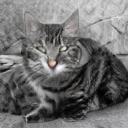

Prediction: AI-generated
AI probability: 0.9989


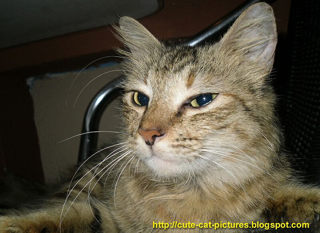

Prediction: nature
AI probability: 0.0015


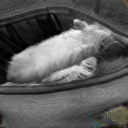

Prediction: AI-generated
AI probability: 0.9981


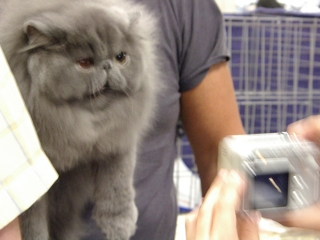

Prediction: nature
AI probability: 0.0018


,path,prediction,pred_ai,ai_probability,threshold,model,feature_set,fft_mag_mean,fft_phase_mean,fft_phase_cos_mean,fft_phase_sin_mean
0,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,AI-generated,1,0.998901,0.5,XGBoost,FFT + CLIP,2216.994629,1.917472e-04,-0.008250,4.656613e-10
1,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,nature,0,0.001545,0.5,XGBoost,FFT + CLIP,12279.830078,2.617288e-10,-0.000022,-1.308644e-10
2,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,AI-generated,1,0.998056,0.5,XGBoost,FFT + CLIP,1636.007812,3.834944e-04,0.021448,-4.656613e-10
3,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,nature,0,0.001770,0.5,XGBoost,FFT + CLIP,3868.362305,-1.953125e-09,-0.016260,8.138021e-11


Saved predictions: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/single_image_inference_fft_clip.csv


In [7]:
def predict_image(image_path, show_image=True):
    image_path, features = extract_fft_clip_features(image_path)
    X_one = pd.DataFrame([features]).reindex(columns=feature_cols)

    missing = X_one.columns[X_one.isna().any()].tolist()
    if missing:
        raise ValueError(f"Fitur tidak lengkap: {missing[:10]}")

    score_ai = float(clf.predict_proba(X_one)[:, 1][0])
    pred_ai = int(score_ai >= threshold)
    label = "AI-generated" if pred_ai == 1 else "nature"

    row = {
        "path": str(image_path),
        "prediction": label,
        "pred_ai": pred_ai,
        "ai_probability": score_ai,
        "threshold": threshold,
        "model": bundle.get("model_name", type(clf).__name__),
        "feature_set": bundle.get("feature_set", "FFT + CLIP"),
        "fft_mag_mean": features["fft_mag_mean"],
        "fft_phase_mean": features["fft_phase_mean"],
        "fft_phase_cos_mean": features["fft_phase_cos_mean"],
        "fft_phase_sin_mean": features["fft_phase_sin_mean"],
    }

    if show_image:
        preview = PILImage.open(image_path).convert("RGB")
        preview.thumbnail((320, 320))
        display(preview)
        print(f"Prediction: {label}")
        print(f"AI probability: {score_ai:.4f}")

    return row


prediction_rows = []
for image_path in TEST_IMAGE_PATHS:
    prediction_rows.append(predict_image(image_path, show_image=True))

predictions_df = pd.DataFrame(prediction_rows)
display(predictions_df)

predictions_df.to_csv(PREDICTION_OUT, index=False)
print("Saved predictions:", PREDICTION_OUT)


## 5. Uji Gambar Tunggal Secara Manual

Cell berikut dapat dipakai berulang kali untuk mengetes satu gambar tertentu tanpa menjalankan ulang seluruh daftar gambar.


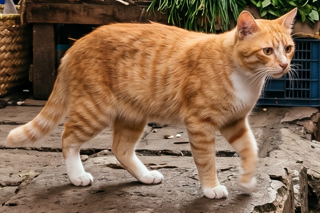

Prediction: nature
AI probability: 0.0857


{'path': '/home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/notebooks/Gemini_Generated_Image_xu54yvxu54yvxu54.png',
 'prediction': 'nature',
 'pred_ai': 0,
 'ai_probability': 0.0857253447175026,
 'threshold': 0.5,
 'model': 'XGBoost',
 'feature_set': 'FFT + CLIP',
 'fft_mag_mean': 11050.18359375,
 'fft_phase_mean': -7.344184723478975e-06,
 'fft_phase_cos_mean': -0.0014629383804276586,
 'fft_phase_sin_mean': 2.853883795950196e-10}

In [12]:
# Ganti path berikut dengan gambar yang ingin diuji.
TEST_IMAGE_PATHS = [
    r"notebooks/Gemini_Generated_Image_xu54yvxu54yvxu54.png",
]

single_image_path = TEST_IMAGE_PATHS[0]

single_result = predict_image(single_image_path, show_image=True)
single_result
